# WBGT Learning Module 3
## Select one African country and calculate labor productivity

**Default country:** Ghana  

This notebook reads the WBGT output from Notebook 2, isolates one country, calculates hourly labor productivity, and creates country-level summaries.

Change one line to use a different country after loading a dataset that covers that country:

```python
COUNTRY_NAME = "Ghana"
```

### Learning goals

By the end, you should be able to:

1. mask a gridded dataset using a national boundary,
2. distinguish daytime from nighttime,
3. calculate ISO-style labor productivity at each time and grid cell,
4. average only after applying the nonlinear labor-response function,
5. compare baseline and future productivity,
6. aggregate results using an explicit spatial weighting choice,
7. export country-level tables and gridded results.

## 1. Relationship to Saeed et al.

Saeed et al. calculate grid-cell labor-capacity changes for multiple work intensities and indoor/outdoor conditions. They use daytime hours and express the future impact relative to baseline capacity.

The full study then applies:

- work-intensity shares,
- indoor/outdoor exposure shares,
- sector and labor-type mappings,
- a GDP-dependent adjustment to outdoor exposure,
- population weights for nonagricultural activities,
- agricultural-production weights for agricultural activities.

This notebook stops before the economic model. It calculates **country-level outdoor labor productivity by work intensity**, which is the natural next stage after the WBGT notebooks.

## 2. Install and import packages

`regionmask` supplies Natural Earth country boundaries. It may download boundary data the first time it is used.

In [1]:
from pathlib import Path
import subprocess
import sys

RUN_INSTALL = False

if RUN_INSTALL:
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "numpy", "pandas", "matplotlib", "xarray",
            "netcdf4", "regionmask", "geopandas",
        ],
        check=True,
    )

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import regionmask

print("Imports successful.")

Imports successful.


## 3. Choose the country and WBGT file

Ghana is the default because it is included in Saeed et al. and lies inside the
domain created in Notebook 2.

This notebook reads the **baseline product from Notebook 2**
(`era5_africa_wbgt_baseline_week.nc`, or a per-country crop under
`wbgt_outputs/country/`). That file provides outdoor WBGT as `wbgt_outdoor_c`;
the loader below renames it to `wbgt_baseline_c` and builds a **teaching-only**
`+2 C` demo future. For the real `+3 C` bias-corrected shock used for GTAP, see
Notebook 4.

The country name must match the Natural Earth name. Examples include:

- `"Ghana"`
- `"Nigeria"`
- `"Senegal"`
- `"Cameroon"`
- `"Burkina Faso"`
- `"Guinea"`

For Côte d'Ivoire, Natural Earth naming can differ by boundary version, so inspect
the available country names when needed.

In [3]:
COUNTRY_NAME = "Ghana"

# Notebook 2 now saves a compact baseline product with wbgt_outdoor_c,
# wbgt_indoor_c and rsds.
#   Continent file:   wbgt_outputs/era5_africa_wbgt_baseline_week.nc
#   Per-country crop: wbgt_outputs/country/<country>_wbgt_baseline.nc
WBGT_FILE = Path("wbgt_outputs/era5_africa_wbgt_baseline_week.nc")

DAYLIGHT_THRESHOLD_WM2 = 5.0
METABOLIC_RATES_W = [200.0, 300.0, 400.0, 600.0]

# Teaching-only warming increment for the demo future scenario.
DEMO_WARMING_C = 2.0

if not WBGT_FILE.exists():
    raise FileNotFoundError(
        f"{WBGT_FILE} was not found. Run Notebook 2 first, or change WBGT_FILE "
        "to your own gridded WBGT NetCDF file."
    )

ds = xr.open_dataset(WBGT_FILE)

# --- Adapt the Notebook 2 baseline product to this notebook's names --------
# Outdoor WBGT arrives as 'wbgt_outdoor_c' (older files used 'wbgt_baseline_c').
if "wbgt_baseline_c" not in ds:
    for alt in ("wbgt_outdoor_c", "wbgt_c", "wbgt"):
        if alt in ds:
            ds = ds.rename({alt: "wbgt_baseline_c"})
            break

# Build the teaching-only demo future if the file does not already carry one.
if "wbgt_future_demo_c" not in ds:
    ds["wbgt_future_demo_c"] = ds["wbgt_baseline_c"] + DEMO_WARMING_C
    ds["wbgt_future_demo_c"].attrs["warning"] = (
        f"Teaching-only: baseline + {DEMO_WARMING_C} C. Not a climate projection. "
        "For the real +3 C bias-corrected shock, use Notebook 4."
    )

ds

<xarray.Dataset> Size: 16MB
Dimensions:             (time: 168, lat: 76, lon: 76)
Coordinates:
  * time                (time) datetime64[ns] 1kB 2020-07-01 ... 2020-07-07T2...
  * lat                 (lat) float64 608B -37.0 -36.0 -35.0 ... 36.0 37.0 38.0
  * lon                 (lon) float64 608B -20.0 -19.0 -18.0 ... 53.0 54.0 55.0
Data variables:
    wbgt_baseline_c     (time, lat, lon) float32 4MB 11.65 11.62 ... 17.3 18.77
    wbgt_indoor_c       (time, lat, lon) float32 4MB ...
    rsds                (time, lat, lon) float32 4MB ...
    wbgt_future_demo_c  (time, lat, lon) float32 4MB 13.65 13.62 ... 19.3 20.77
Attributes:
    method:     Pure-Python explicit Liljegren WBGT (outdoor + indoor)
    data_mode:  aws
    period:     2020-07-01T00:00 to 2020-07-07T23:00 (hourly)
    note:       Baseline WBGT product for Notebook 4. Indoor: shortwave=0, wi...

## 4. Check the required variables

After the loader above, this notebook works with:

- `wbgt_baseline_c` (renamed from Notebook 2's `wbgt_outdoor_c`)
- `wbgt_future_demo_c` (teaching-only, built as baseline + 2 C if absent)
- `rsds`
- `time`, `lat`, and `lon`

If you bring your own file with different names, rename them before continuing.

In [4]:
required_variables = [
    "wbgt_baseline_c",
    "wbgt_future_demo_c",
    "rsds",
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in ds
]

if missing_variables:
    raise KeyError(
        f"Missing variables: {missing_variables}"
    )

required_coordinates = ["time", "lat", "lon"]

missing_coordinates = [
    coordinate
    for coordinate in required_coordinates
    if coordinate not in ds.coords
]

if missing_coordinates:
    raise KeyError(
        f"Missing coordinates: {missing_coordinates}"
    )

print("Required variables and coordinates are present.")

Required variables and coordinates are present.


## 5. Load country boundaries

Different `regionmask` versions expose different Natural Earth releases. The helper function selects a release that is available in the installed version.

In [5]:
def load_country_regions():
    """Return an available Natural Earth country boundary set."""

    version_names = [
        "natural_earth_v5_1_2",
        "natural_earth_v5_0_0",
        "natural_earth_v4_1_0",
    ]

    for version_name in version_names:
        if hasattr(
            regionmask.defined_regions,
            version_name,
        ):
            version = getattr(
                regionmask.defined_regions,
                version_name,
            )
            return version.countries_110

    raise AttributeError(
        "No supported Natural Earth country boundary "
        "set was found in this regionmask version."
    )


countries = load_country_regions()

print("Number of country regions:", len(countries))

Number of country regions: 177


## 6. Find the requested country and build its mask

In [6]:
def find_country_number(regions, country_name):
    """Find a regionmask country number from its name."""

    exact_matches = [
        number
        for number, name in zip(
            regions.numbers,
            regions.names,
        )
        if name.casefold() == country_name.casefold()
    ]

    if exact_matches:
        return exact_matches[0]

    partial_matches = [
        name
        for name in regions.names
        if country_name.casefold() in name.casefold()
    ]

    raise ValueError(
        f"Country {country_name!r} was not found. "
        f"Possible partial matches: {partial_matches[:10]}"
    )


country_number = find_country_number(
    countries,
    COUNTRY_NAME,
)

country_id_mask = countries.mask(
    ds["lon"],
    ds["lat"],
    wrap_lon=False,
)

inside_country = (
    country_id_mask == country_number
)

number_of_grid_cells = int(
    inside_country.sum()
)

if number_of_grid_cells == 0:
    raise ValueError(
        f"No grid-cell centers fall inside {COUNTRY_NAME}. "
        "Use a finer grid or check the data domain."
    )

print(
    f"{COUNTRY_NAME}: "
    f"{number_of_grid_cells} grid-cell centers selected."
)

Ghana: 20 grid-cell centers selected.


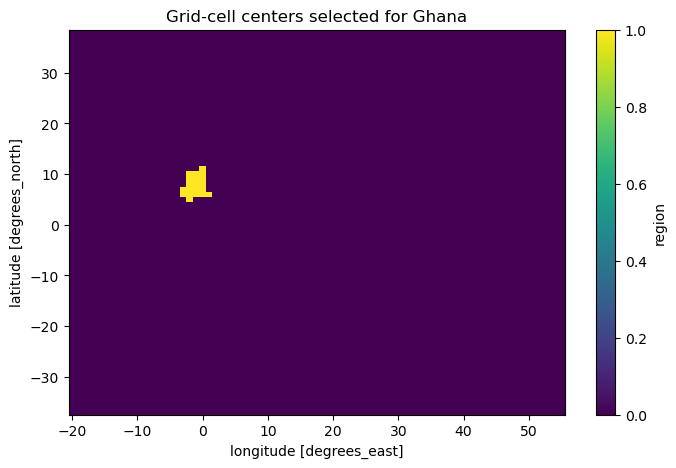

In [7]:
plt.figure(figsize=(8, 5))
inside_country.astype(int).plot(
    x="lon",
    y="lat",
)
plt.title(
    f"Grid-cell centers selected for {COUNTRY_NAME}"
)
plt.show()

### Important spatial note

A grid cell is selected here when its **center point** lies inside the country polygon. Note: boundary cells may need fractional-area treatment in a publication-quality analysis.

Never use a rectangular bounding box as the final country mask.

## 7. Mask the WBGT dataset to the country

In [8]:
country = ds.where(
    inside_country
)

country[[
    "wbgt_baseline_c",
    "wbgt_future_demo_c",
    "rsds",
]]

<xarray.Dataset> Size: 12MB
Dimensions:             (time: 168, lat: 76, lon: 76)
Coordinates:
  * time                (time) datetime64[ns] 1kB 2020-07-01 ... 2020-07-07T2...
  * lat                 (lat) float64 608B -37.0 -36.0 -35.0 ... 36.0 37.0 38.0
  * lon                 (lon) float64 608B -20.0 -19.0 -18.0 ... 53.0 54.0 55.0
Data variables:
    wbgt_baseline_c     (time, lat, lon) float32 4MB nan nan nan ... nan nan nan
    wbgt_future_demo_c  (time, lat, lon) float32 4MB nan nan nan ... nan nan nan
    rsds                (time, lat, lon) float32 4MB nan nan nan ... nan nan nan
Attributes:
    method:     Pure-Python explicit Liljegren WBGT (outdoor + indoor)
    data_mode:  aws
    period:     2020-07-01T00:00 to 2020-07-07T23:00 (hourly)
    note:       Baseline WBGT product for Notebook 4. Indoor: shortwave=0, wi...

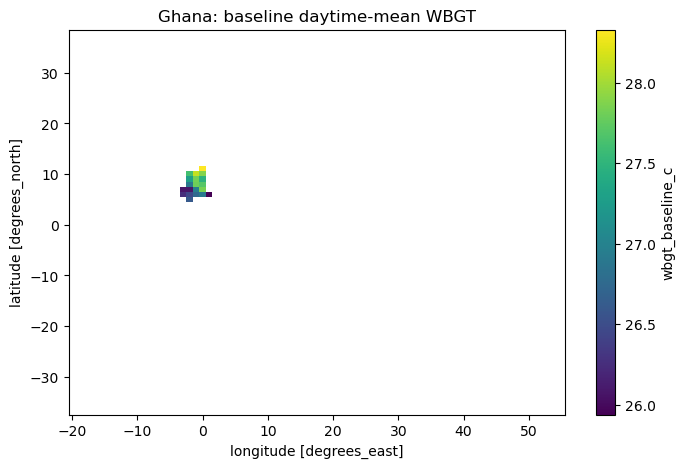

In [9]:
baseline_daytime_mean_wbgt = (
    country["wbgt_baseline_c"]
    .where(
        country["rsds"]
        > DAYLIGHT_THRESHOLD_WM2
    )
    .mean("time")
)

plt.figure(figsize=(8, 5))
baseline_daytime_mean_wbgt.plot(
    x="lon",
    y="lat",
)
plt.title(
    f"{COUNTRY_NAME}: baseline daytime-mean WBGT"
)
plt.show()

## 8. Define the ISO-style labor-productivity function

The WBGT limit for metabolic rate \(M\), in watts, is:

\[
WBGT_{lim} = 56.7 - 11.5\log_{10}(M)
\]

The work fraction is:

\[
P =
\max\left[
0,\,
\min\left(
1,\,
\frac{WBGT_{lim,rest}-WBGT}
{WBGT_{lim,rest}-WBGT_{lim,work}}
\right)
\right]
\]

where the resting metabolic rate is 117 W.

Interpretation:

- 1.00 = full hour available for work,
- 0.50 = approximately 30 minutes work and 30 minutes rest,
- 0.00 = no work time under this work-rest interpretation.

In [10]:
def iso_wbgt_limit_c(metabolic_rate_w):
    """WBGT limit in degrees C."""
    return (
        56.7
        - 11.5
        * np.log10(metabolic_rate_w)
    )


def iso_labor_productivity(
    wbgt_c,
    metabolic_rate_w,
):
    """Labor productivity as a fraction from 0 to 1."""

    work_limit_c = iso_wbgt_limit_c(
        metabolic_rate_w
    )

    rest_limit_c = iso_wbgt_limit_c(
        117.0
    )

    productivity = (
        rest_limit_c - wbgt_c
    ) / (
        rest_limit_c - work_limit_c
    )

    return np.clip(
        productivity,
        0.0,
        1.0,
    )

In [11]:
limit_table = pd.DataFrame({
    "Metabolic rate (W)": METABOLIC_RATES_W,
    "WBGT work limit (°C)": [
        iso_wbgt_limit_c(m)
        for m in METABOLIC_RATES_W
    ],
})

limit_table.round(2)

,Metabolic rate (W),WBGT work limit (°C)
0,200.0,30.24
1,300.0,28.21
2,400.0,26.78
3,600.0,24.75


## 9. Calculate productivity at every daytime time step and grid cell

This ordering is essential:

1. calculate high-frequency WBGT,
2. apply the nonlinear productivity function,
3. select or retain daytime values,
4. then average.

Do not average WBGT first and apply the productivity function afterward.

In [12]:
daytime = (
    country["rsds"]
    > DAYLIGHT_THRESHOLD_WM2
)

productivity = xr.Dataset()

for metabolic_rate in METABOLIC_RATES_W:
    suffix = f"{int(metabolic_rate)}W"

    baseline_productivity = xr.apply_ufunc(
        iso_labor_productivity,
        country["wbgt_baseline_c"],
        metabolic_rate,
    ).where(daytime)

    future_productivity = xr.apply_ufunc(
        iso_labor_productivity,
        country["wbgt_future_demo_c"],
        metabolic_rate,
    ).where(daytime)

    productivity[
        f"baseline_{suffix}"
    ] = baseline_productivity

    productivity[
        f"future_{suffix}"
    ] = future_productivity

productivity

<xarray.Dataset> Size: 62MB
Dimensions:        (lat: 76, time: 168, lon: 76)
Coordinates:
  * lat            (lat) float64 608B -37.0 -36.0 -35.0 -34.0 ... 36.0 37.0 38.0
  * time           (time) datetime64[ns] 1kB 2020-07-01 ... 2020-07-07T23:00:00
  * lon            (lon) float64 608B -20.0 -19.0 -18.0 -17.0 ... 53.0 54.0 55.0
Data variables:
    baseline_200W  (time, lat, lon) float64 8MB nan nan nan nan ... nan nan nan
    future_200W    (time, lat, lon) float64 8MB nan nan nan nan ... nan nan nan
    baseline_300W  (time, lat, lon) float64 8MB nan nan nan nan ... nan nan nan
    future_300W    (time, lat, lon) float64 8MB nan nan nan nan ... nan nan nan
    baseline_400W  (time, lat, lon) float64 8MB nan nan nan nan ... nan nan nan
    future_400W    (time, lat, lon) float64 8MB nan nan nan nan ... nan nan nan
    baseline_600W  (time, lat, lon) float64 8MB nan nan nan nan ... nan nan nan
    future_600W    (time, lat, lon) float64 8MB nan nan nan nan ... nan nan nan

## 10. Choose spatial weights

Saeed et al. use:

- population weights for nonagricultural activities,
- agricultural-production weights for agricultural activities.

This notebook uses grid-cell area weights as a runnable fallback. Replace them with a real population or agricultural-production field for the final study.

For a regular latitude-longitude grid, the cosine of latitude is a simple approximation to relative grid-cell area.

In [13]:
latitude_area_weight = np.cos(
    np.deg2rad(ds["lat"])
)

area_weights = (
    latitude_area_weight
    .broadcast_like(inside_country)
    .where(inside_country)
)

SPATIAL_WEIGHT_DESCRIPTION = (
    "Cosine-latitude area weights; teaching fallback only"
)

area_weights

<xarray.DataArray 'lat' (lat: 76, lon: 76)> Size: 46kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(76, 76))
Coordinates:
  * lat      (lat) float64 608B -37.0 -36.0 -35.0 -34.0 ... 35.0 36.0 37.0 38.0
  * lon      (lon) float64 608B -20.0 -19.0 -18.0 -17.0 ... 52.0 53.0 54.0 55.0
Attributes:
    long_name:   latitude
    short_name:  lat
    units:       degrees_north

### Replacing the fallback with population weights

After opening and regridding a population dataset:

```python
population_weights = population_on_wbgt_grid.where(inside_country)
spatial_weights = population_weights
```

For agricultural labor, use agricultural-production weights rather than population weights.

In [14]:
spatial_weights = area_weights

## 11. Country-level productivity summary

We first average daytime productivity through time at each grid cell. We then calculate a weighted country mean.

The output reports:

- baseline productivity,
- future productivity,
- absolute change in percentage points,
- relative loss as a percentage of baseline productivity.

In [15]:
def weighted_spatial_mean(
    data,
    weights,
    dimensions=("lat", "lon"),
):
    """Weighted mean that ignores missing data."""

    valid_weights = weights.where(
        data.notnull()
    )

    numerator = (
        data * valid_weights
    ).sum(dimensions)

    denominator = valid_weights.sum(
        dimensions
    )

    return numerator / denominator


summary_rows = []
loss_maps = xr.Dataset()

for metabolic_rate in METABOLIC_RATES_W:
    suffix = f"{int(metabolic_rate)}W"

    baseline_grid_mean = (
        productivity[f"baseline_{suffix}"]
        .mean("time")
    )

    future_grid_mean = (
        productivity[f"future_{suffix}"]
        .mean("time")
    )

    baseline_country_mean = float(
        weighted_spatial_mean(
            baseline_grid_mean,
            spatial_weights,
        )
    )

    future_country_mean = float(
        weighted_spatial_mean(
            future_grid_mean,
            spatial_weights,
        )
    )

    absolute_change_points = (
        100.0
        * (
            future_country_mean
            - baseline_country_mean
        )
    )

    if baseline_country_mean > 0.0:
        relative_loss_pct = (
            100.0
            * (
                baseline_country_mean
                - future_country_mean
            )
            / baseline_country_mean
        )
    else:
        relative_loss_pct = np.nan

    grid_relative_loss_pct = (
        100.0
        * (
            baseline_grid_mean
            - future_grid_mean
        )
        / baseline_grid_mean
    ).where(
        baseline_grid_mean > 0.0
    )

    loss_maps[
        f"relative_loss_{suffix}_pct"
    ] = grid_relative_loss_pct

    summary_rows.append({
        "Country": COUNTRY_NAME,
        "Metabolic rate (W)": metabolic_rate,
        "Baseline productivity (%)": (
            100.0 * baseline_country_mean
        ),
        "Future productivity (%)": (
            100.0 * future_country_mean
        ),
        "Absolute change (percentage points)": (
            absolute_change_points
        ),
        "Relative productivity loss (%)": (
            relative_loss_pct
        ),
        "Spatial weighting": (
            SPATIAL_WEIGHT_DESCRIPTION
        ),
    })

country_summary = pd.DataFrame(
    summary_rows
)

country_summary.round(2)

,Country,Metabolic rate (W),Baseline productivity (%),Future productivity (%),Absolute change (percentage points),Relative productivity loss (%),Spatial weighting
0,Ghana,200.0,98.10,84.16,-13.94,14.21,Cosine-latitude area weights; teaching fallbac...
1,Ghana,300.0,90.50,70.41,-20.08,22.19,Cosine-latitude area weights; teaching fallbac...
2,Ghana,400.0,82.63,59.77,-22.86,27.67,Cosine-latitude area weights; teaching fallbac...
3,Ghana,600.0,69.31,46.44,-22.87,32.99,Cosine-latitude area weights; teaching fallbac...


## 12. Plot productivity by work intensity

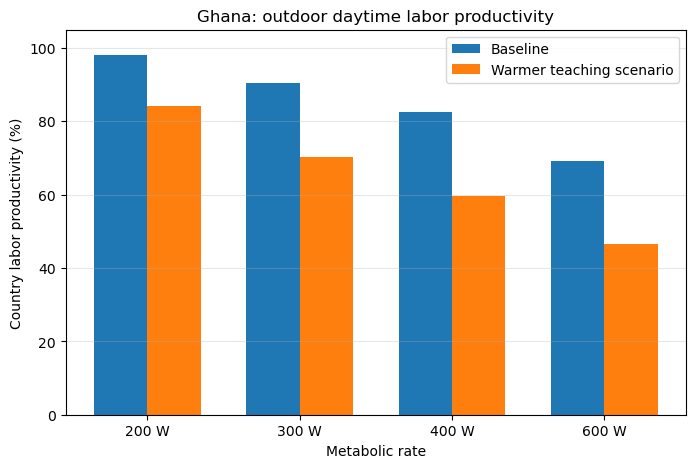

In [16]:
plot_table = (
    country_summary
    .set_index("Metabolic rate (W)")
)

x = np.arange(
    len(plot_table)
)

width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    plot_table["Baseline productivity (%)"],
    width,
    label="Baseline",
)

plt.bar(
    x + width / 2,
    plot_table["Future productivity (%)"],
    width,
    label="Warmer teaching scenario",
)

plt.xticks(
    x,
    [
        f"{int(value)} W"
        for value in plot_table.index
    ],
)

plt.ylabel("Country labor productivity (%)")
plt.xlabel("Metabolic rate")
plt.title(
    f"{COUNTRY_NAME}: outdoor daytime labor productivity"
)
plt.ylim(0, 105)
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3,
)
plt.show()

## 13. Map the relative productivity loss

Choose one work intensity for the map.

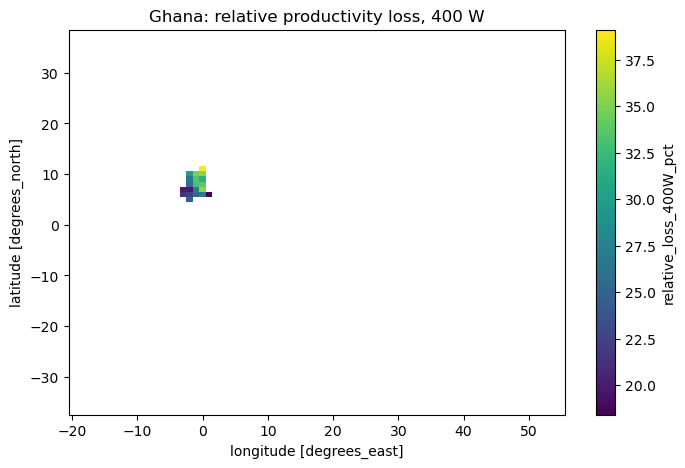

In [17]:
MAP_METABOLIC_RATE_W = 400.0
map_variable = (
    f"relative_loss_"
    f"{int(MAP_METABOLIC_RATE_W)}W_pct"
)

plt.figure(figsize=(8, 5))

loss_maps[map_variable].plot(
    x="lon",
    y="lat",
)

plt.title(
    f"{COUNTRY_NAME}: relative productivity loss, "
    f"{MAP_METABOLIC_RATE_W:.0f} W"
)
plt.show()

## 14. Inspect a country-average time series

The weighted country-average WBGT and productivity time series help identify when the largest labor impacts occur.

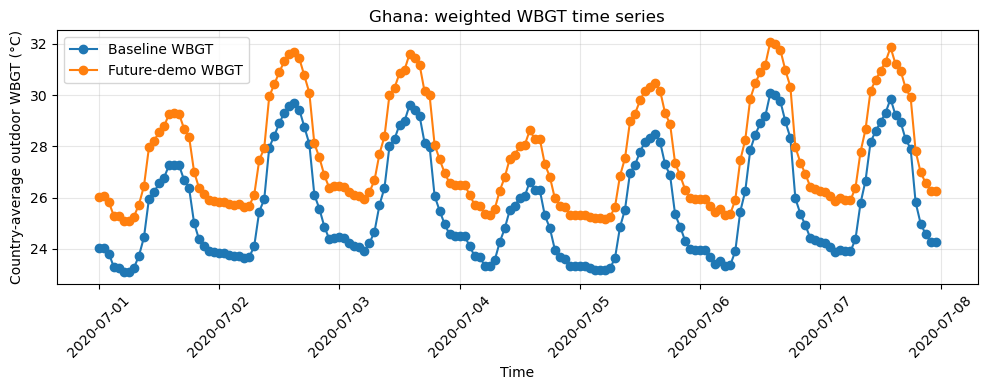

In [18]:
country_mean_baseline_wbgt = weighted_spatial_mean(
    country["wbgt_baseline_c"],
    spatial_weights,
)

country_mean_future_wbgt = weighted_spatial_mean(
    country["wbgt_future_demo_c"],
    spatial_weights,
)

plt.figure(figsize=(10, 4))

plt.plot(
    country_mean_baseline_wbgt["time"],
    country_mean_baseline_wbgt,
    marker="o",
    label="Baseline WBGT",
)

plt.plot(
    country_mean_future_wbgt["time"],
    country_mean_future_wbgt,
    marker="o",
    label="Future-demo WBGT",
)

plt.ylabel("Country-average outdoor WBGT (°C)")
plt.xlabel("Time")
plt.title(
    f"{COUNTRY_NAME}: weighted WBGT time series"
)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

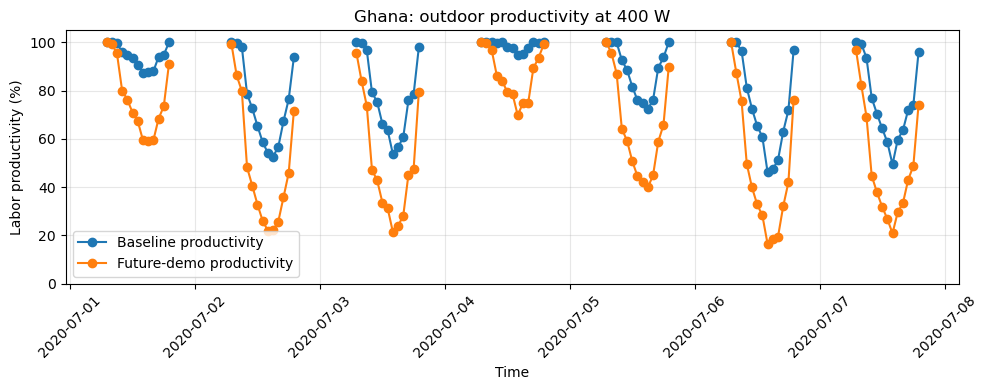

In [19]:
selected_rate = 400.0
selected_suffix = f"{int(selected_rate)}W"

country_mean_baseline_productivity = (
    weighted_spatial_mean(
        productivity[
            f"baseline_{selected_suffix}"
        ],
        spatial_weights,
    )
)

country_mean_future_productivity = (
    weighted_spatial_mean(
        productivity[
            f"future_{selected_suffix}"
        ],
        spatial_weights,
    )
)

plt.figure(figsize=(10, 4))

plt.plot(
    country_mean_baseline_productivity["time"],
    100.0 * country_mean_baseline_productivity,
    marker="o",
    label="Baseline productivity",
)

plt.plot(
    country_mean_future_productivity["time"],
    100.0 * country_mean_future_productivity,
    marker="o",
    label="Future-demo productivity",
)

plt.ylabel("Labor productivity (%)")
plt.xlabel("Time")
plt.title(
    f"{COUNTRY_NAME}: outdoor productivity at "
    f"{selected_rate:.0f} W"
)
plt.ylim(0, 105)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Export country results

In [20]:
output_directory = Path("country_outputs")
output_directory.mkdir(exist_ok=True)

safe_country_name = (
    COUNTRY_NAME
    .lower()
    .replace(" ", "_")
    .replace("'", "")
)

summary_path = (
    output_directory
    / f"{safe_country_name}_labor_productivity_summary.csv"
)

maps_path = (
    output_directory
    / f"{safe_country_name}_labor_productivity_loss_maps.nc"
)

country_summary.to_csv(
    summary_path,
    index=False,
)

loss_maps.attrs.update({
    "country": COUNTRY_NAME,
    "spatial_weighting": (
        SPATIAL_WEIGHT_DESCRIPTION
    ),
    "warning": (
        "The default input uses a synthetic teaching scenario."
    ),
})

loss_maps.to_netcdf(
    maps_path
)

print("Saved:", summary_path.resolve())
print("Saved:", maps_path.resolve())

Saved: /Users/junghawoo/Documents/GLASSNET_ECR/country_outputs/ghana_labor_productivity_summary.csv
Saved: /Users/junghawoo/Documents/GLASSNET_ECR/country_outputs/ghana_labor_productivity_loss_maps.nc


## 16. Extending this notebook toward the Saeed study

The next research steps are:

1. replace area weights with population weights for nonagricultural work,
2. replace area weights with agricultural-production weights for agricultural work,
3. calculate the exact indoor WBGT method used by the study,
4. add work-intensity and indoor/outdoor shares by labor type and sector,
5. apply the documented adjustment to outdoor work shares,
6. aggregate baseline-to-future losses by country, sector, and labor type,
7. validate one published country result before adding new African countries,
8. pass the resulting productivity shocks to the chosen economic model.

The output of this notebook is therefore a country-level climate-and-labor module, not a complete poverty-impact replication.

## 17. Common mistakes

- Applying a labor function to daily or monthly mean WBGT.
- Including nighttime when the analysis is defined for daytime work.
- Averaging WBGT before calculating hourly productivity.
- Using a country bounding box instead of a polygon mask.
- Calling area weighting population weighting.
- Using population weights for agricultural production without justification.
- Mixing productivity loss in percentage points with relative percentage loss.

## References

- Kong, Q., & Huber, M. (2022). *Explicit calculations of wet-bulb globe temperature compared with approximations and why it matters for labor productivity*. Earth's Future, 10, e2021EF002334.
- Saeed, W., et al. (2022). *The poverty impacts of labor heat stress in West Africa under a warming climate*. Earth's Future, 10, e2022EF002777.